In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.animation import FuncAnimation
import cv2 as cv
from kwave.kgrid import kWaveGrid
from kwave.kmedium import kWaveMedium
from kwave.ksource import kSource
from kwave.ksensor import kSensor
from kwave.kspaceFirstOrder2D import kspaceFirstOrder2D
rndseed = 42 
np.random.seed(rndseed)

In [2]:
# define the computational grid
dx = 50e-6 # grid point spacing in the x and y direction [m]
dy = 50e-6 # grid point spacing in the x and y direction [m]
Nx = 1024  # number of grid points in the x direction
Ny = 1024  # number of grd points in the y direction

grid = kWaveGrid([Nx, Ny], [dx, dy]) 
X , Y = np.meshgrid(grid.x_vec, grid.y_vec , indexing='ij')
"""grid.Nt = 10 # time step [s]
grid.makeTime(c=1540, t_end=1e-6 ,cfl= 0.1)  # CFL number of 0.3 and end time of 1 ms
# Create time array if not already present
if not hasattr(grid, 't_array') or grid.t_array is None:
    grid.t_array = np.arange(0, 3, grid.dt)  # time array from 0 to 1 second"""

grid.makeTime(c=1540, t_end=2e-5, cfl=0.1)

(array([[0.00000000e+00, 3.24675325e-09, 6.49350649e-09, ...,
         1.99935065e-05, 1.99967532e-05, 2.00000000e-05]], shape=(1, 6161)),
 np.float64(3.246753246753247e-09))

In [3]:
num_data = 3  # number of different medium maps to generate

def generate_breast_medium_maps(n, Nx, Ny, dx, dy, max_num_tumors=3):
    np.random.seed(rndseed)  # For reproducibility
    """
    Generates n sets of aligned Speed of Sound (SoS) and Density (rho) maps.
    Tumors include internal heterogeneity (porosity) with a variance of 0.8.
    """
    sos_list = []
    rho_list = []
    
    x = np.linspace(0, (Nx-1)*dx, Nx)
    y = np.linspace(0, (Ny-1)*dy, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')

    for _ in range(n):
        # 1. Healthy Background Medium
        # SoS range [1433-1565] m/s, Density range [920-1060] kg/m^3
        bg_sos_val = np.random.uniform(1450, 1540)
        bg_rho_val = np.random.uniform(950, 1020)
        
        # Background variance
        sos_map = np.random.normal(bg_sos_val, 2.5, (Nx, Ny))
        rho_map = np.random.normal(bg_rho_val, 2.5, (Nx, Ny))
        
        # 2. Add Correlated Tumors
        num_tumors = np.random.randint(1, max_num_tumors + 1)
        for _ in range(num_tumors):
            # Geometry
            t_cx = np.random.randint(int(0.1*Nx), int(0.9*Nx)) * dx
            t_cy = np.random.randint(int(0.1*Ny), int(0.9*Ny)) * dy
            t_rx = np.random.uniform(10, 50) * dx*5
            t_ry = np.random.uniform(10, 30) * dx*5
            angle = np.random.uniform(0, np.pi)
            
            X_rot = (X - t_cx) * np.cos(angle) + (Y - t_cy) * np.sin(angle)
            Y_rot = -(X - t_cx) * np.sin(angle) + (Y - t_cy) * np.cos(angle)
            mask = (X_rot**2 / t_rx**2 + Y_rot**2 / t_ry**2) <= 1
            
            # Base values for tumor
            if np.random.rand() > 0.3:
                t_sos = np.random.uniform(1550, 1700)
                t_rho = np.random.uniform(1040, 1100)
            else:
                t_sos = np.random.uniform(1300, 1450)
                t_rho = np.random.uniform(900, 940)

            # --- Apply Porosity ---
            # Using 0.8 as the scale (standard deviation) for internal variance
            # standard_deviation = sqrt(variance) -> if variance=1.5, scale ~0.89
            # If you meant scale=0.8, the code below applies it directly:
            tumor_internal_noise_sos = np.random.normal(0, 1.5, size=np.sum(mask))
            tumor_internal_noise_rho = np.random.normal(0, 1.5, size=np.sum(mask))

            sos_map[mask] = t_sos + tumor_internal_noise_sos
            rho_map[mask] = t_rho + tumor_internal_noise_rho
            
        sos_list.append(sos_map)
        rho_list.append(rho_map)
        
    return sos_list, rho_list

# Execution
sos_maps, den_maps = generate_breast_medium_maps(n=num_data, Nx=Nx, Ny=Ny, dx=dx, dy=dy, max_num_tumors=3)


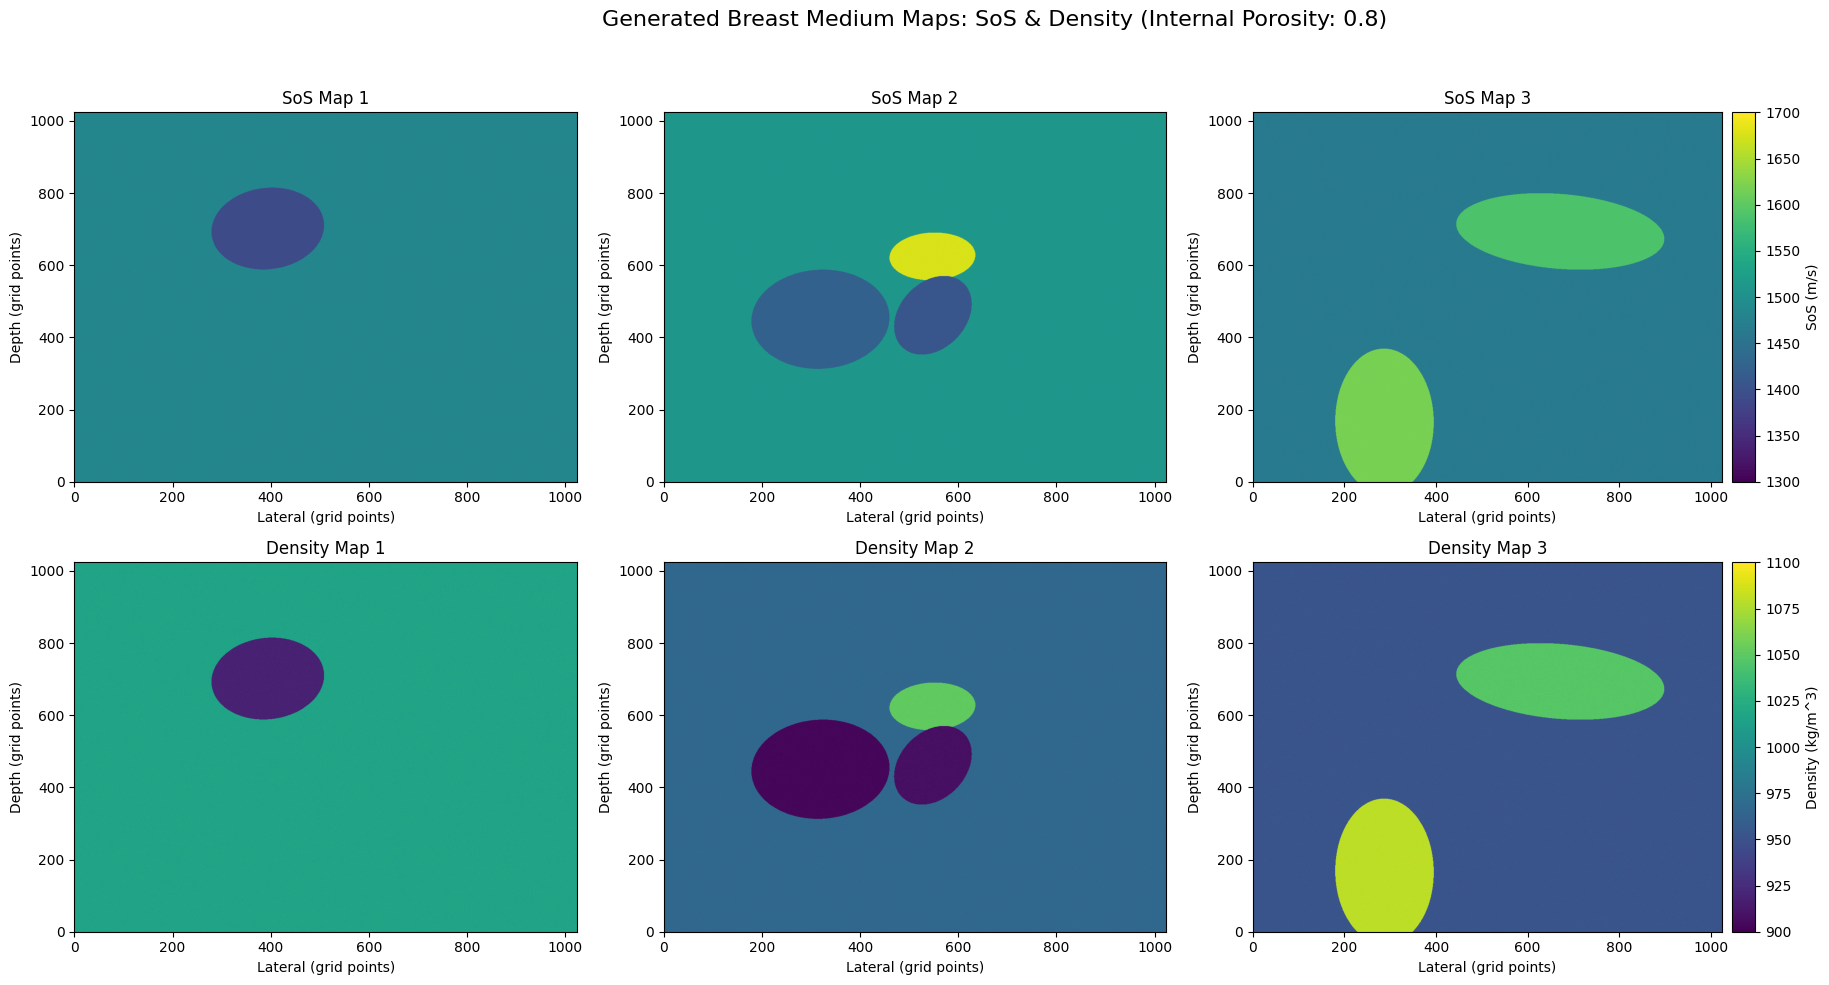

In [4]:
for i in range(num_data):
    sos_maps[i] = sos_maps[i][::-1, :].T  # Flip the map vertically to have Depth 0 at the bottom
    den_maps[i] = den_maps[i][::-1, :].T # Flip the map vertically to have Depth 0 at the bottom

# Assuming num_data is the number of maps generated
fig, axes = plt.subplots(2, num_data, figsize=(20, 10))

for i in range(num_data):
    # --- Plot SoS Map ---
    # Fixed extent: [0, Nx, 0, Ny] ensures Depth 0 is at the top and Ny is at the bottom
    im1 = axes[0, i].imshow(sos_maps[i].T[::-1 , :], extent=[0, Nx, 0, Ny], cmap='viridis', aspect='auto', vmin=1300, vmax=1700)
    axes[0, i].set_title(f'SoS Map {i+1}')
    axes[0, i].set_xlabel('Lateral (grid points)')
    axes[0, i].set_ylabel('Depth (grid points)')
    
    # Corrected colorbar logic to use num_data index
    if i == num_data - 1:
        divider1 = make_axes_locatable(axes[0, i])
        cax1 = divider1.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im1, cax=cax1, label='SoS (m/s)')

    # --- Plot Density Map ---
    im2 = axes[1, i].imshow(den_maps[i].T[::-1 , :], extent=[0, Nx, 0, Ny], cmap='viridis', aspect='auto', vmin=900, vmax=1100)
    axes[1, i].set_title(f'Density Map {i+1}')
    axes[1, i].set_xlabel('Lateral (grid points)')
    axes[1, i].set_ylabel('Depth (grid points)')
    
    # Corrected colorbar logic for density row
    if i == num_data - 1:
        divider2 = make_axes_locatable(axes[1, i])
        cax2 = divider2.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(im2, cax=cax2, label='Density (kg/m^3)')

plt.suptitle('Generated Breast Medium Maps: SoS & Density (Internal Porosity: 0.8)', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.92, 0.95]) 
plt.show()

In [5]:
medium= [] 
for i in range(num_data):
    medium.append(kWaveMedium(sound_speed=sos_maps[i], density=den_maps[i]))

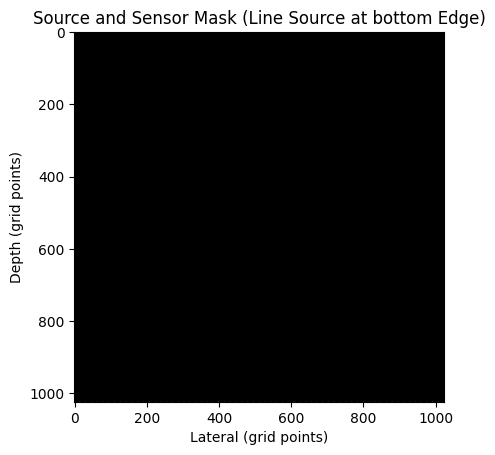

In [8]:
#defining the source and sensor (sonoghraphic setup) : 
s_mask = np.zeros((Nx, Ny), dtype=bool)
s_mask[-1,::16] = True  # Line source at the bottom edge
#ploting the source pos in the map 
plt.imshow(s_mask, cmap='gray')
plt.title('Source and Sensor Mask (Line Source at bottom Edge)')
plt.xlabel('Lateral (grid points)')
plt.ylabel('Depth (grid points)')
plt.show()

#defining the sensors :
sensor = kSensor(mask=s_mask, record=['p'])


In [9]:
s_mask[-1,5:20]

array([False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False])

In [10]:
# 1. Create the base pulse (Tone Burst)
source = kSource()
amplitude  = 1
num_cycles = 3
f0 = 5e6 # 30 MHz center frequency
t_pulse = np.arange(0, num_cycles / f0, grid.dt)
# Gaussian windowed sine wave
pulse_signal = amplitude * np.sin(2 * np.pi * f0 * t_pulse) * np.exp(-((t_pulse - t_pulse[-1]/2)**2) / (2 * (t_pulse[-1]/6)**2))

# Pad with zeros to match simulation time
source_signal = np.zeros(grid.Nt)
source_signal[:len(pulse_signal)] = pulse_signal
# # Define focal point (e.g., 15mm deep in the center)
# x_focus = Nx*dx//2 + 15e-3 
# y_focus = Ny*dy//2 

# # Get coordinates of all active source elements
# element_idx = np.where(s_mask)
# x_coords = X[element_idx]
# y_coords = Y[element_idx]

# # Calculate distances to focus
# distances = np.sqrt((x_coords - x_focus)**2 + (y_coords - y_focus)**2)

# # Convert distance to time delays (relative to the furthest element)
# sound_speed = 1540 # [m/s]
# time_delays = (np.max(distances) - distances) / sound_speed
# delay_offsets = np.round(time_delays / grid.dt).astype(int)


source.p_mask = s_mask.astype(float)
# source.p should have shape (num_source_elements, num_time_steps) 
num_source_elements = int(np.sum(s_mask))
source.p = np.tile(source_signal.reshape(1, -1), (num_source_elements, 1))  # set the source pressure signal


# #Create the Apodization Weights (Hann Window)
# # We normalize the position of elements from 0 to 1 across the width
# y_min, y_max = np.min(y_coords), np.max(y_coords)
# normalized_y = (y_coords - y_min) / (y_max - y_min)

# # Calculate Hann weights: 0.5 * (1 - cos(2 * pi * n))
# apodization_weights = 0.5 * (1 - np.cos(2 * np.pi * normalized_y))

# Apply weights to source.p
# Assuming you already have your source.p matrix (num_elements, num_time_steps)
# We multiply each row (element) by its corresponding weight
#source.p = source.p * apodization_weights.reshape(-1, 1) 

In [11]:
from kwave.options.simulation_options import SimulationOptions
from kwave.options.simulation_execution_options import SimulationExecutionOptions
sim_options = SimulationOptions(pml_inside=False, save_to_disk=True)
exec_options = SimulationExecutionOptions(is_gpu_simulation=False)

sensor_data = kspaceFirstOrder2D(grid, source, sensor, medium[2], simulation_options=sim_options, execution_options=exec_options)

┌───────────────────────────────────────────────────────────────┐
│                   kspaceFirstOrder-OMP v1.3                   │
├───────────────────────────────────────────────────────────────┤
│ Reading simulation configuration:                        Done │
│ Number of CPU threads:                                      8 │
│ Processor name:                                               │
├───────────────────────────────────────────────────────────────┤
│                      Simulation details                       │
├───────────────────────────────────────────────────────────────┤
│ Domain dimensions:                                1064 x 1064 │
│ Medium type:                                               2D │
│ Simulation time steps:                                   6161 │
├───────────────────────────────────────────────────────────────┤
│                        Initialization                         │
├───────────────────────────────────────────────────────────────┤
│ Memory a

In [ ]:
R =sensor_data['p']

{'Nt': array(6161, dtype=uint64),
 'Nx': array(1064, dtype=uint64),
 'Ny': array(1064, dtype=uint64),
 'Nz': array(1, dtype=uint64),
 'absorbing_flag': array(0, dtype=uint64),
 'axisymmetric_flag': array(0, dtype=uint64),
 'c_ref': array(1623.6448, dtype=float32),
 'dt': array(3.2467533e-09, dtype=float32),
 'dx': array(5.e-05, dtype=float32),
 'dy': array(5.e-05, dtype=float32),
 'nonlinear_flag': array(0, dtype=uint64),
 'nonuniform_grid_flag': array(0, dtype=uint64),
 'p': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.0002349 ,  0.00023494,  0.00023535, ...,  0.00023483,
          0.00023508,  0.00023493],
        [ 0.00073564,  0.00073573,  0.00073696, ...,  0.00073541,
          0.00073618,  0.00073571],
        ...,
        [-0.01623815, -0.01631756, -0.01681888, ..., -0.01506994,
         -0.01622986, -0.01836835],
        [-0.0163727 , -0.01647726, -0.01689155, ..., -0.015227  ,
         -0.01626152, -0.01851806

In [13]:
sensor_data['p'] != np.nan

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], shape=(6161, 64))

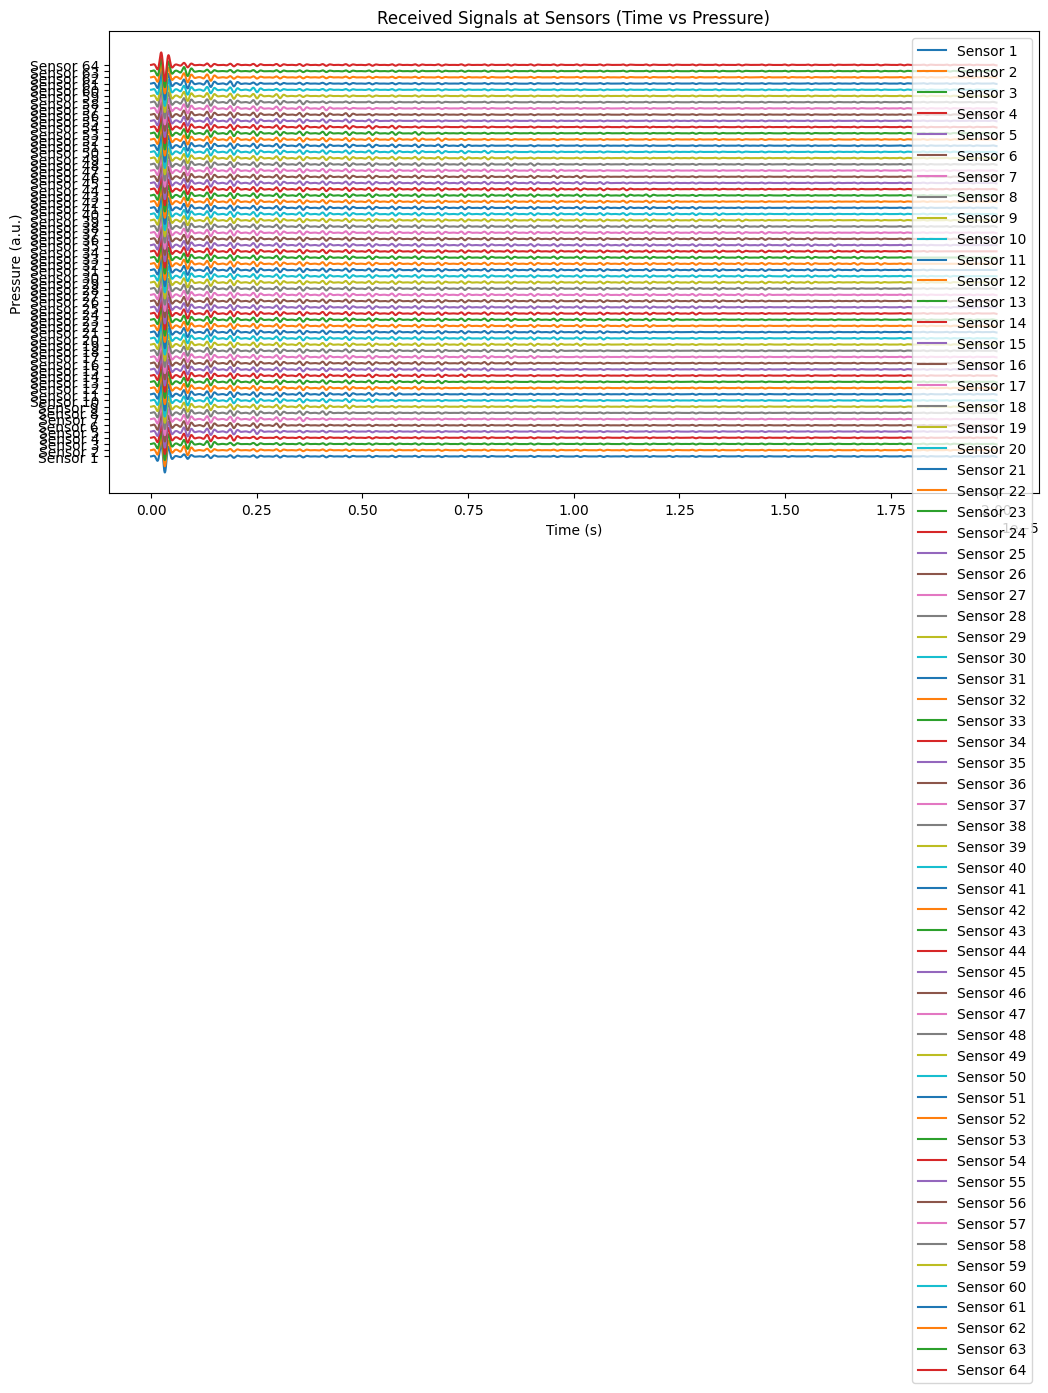

In [14]:
# sensor_data['p'][time,sensor_element] gives the pressure at a specific time and sensor element.
#ploting the received signals at the sensors in parallel channels :
plt.figure(figsize=(12, 6))
for i in range(sensor_data['p'].shape[1]):
    plt.plot(grid.t_array.flatten(), 2*sensor_data['p'][:, i] + i*0.5, label=f'Sensor {i+1}')  # Offset each signal for visibility
plt.title('Received Signals at Sensors (Time vs Pressure)')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (a.u.)')
plt.yticks(np.arange(0, sensor_data['p'].shape[1]*0.5, 0.5), [f'Sensor {i+1}' for i in range(sensor_data['p'].shape[1])])
plt.legend(loc='upper right')
plt.show()

/Users/aliradameli/Desktop/projects/Breast_SoS_Project/SoS_DL/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


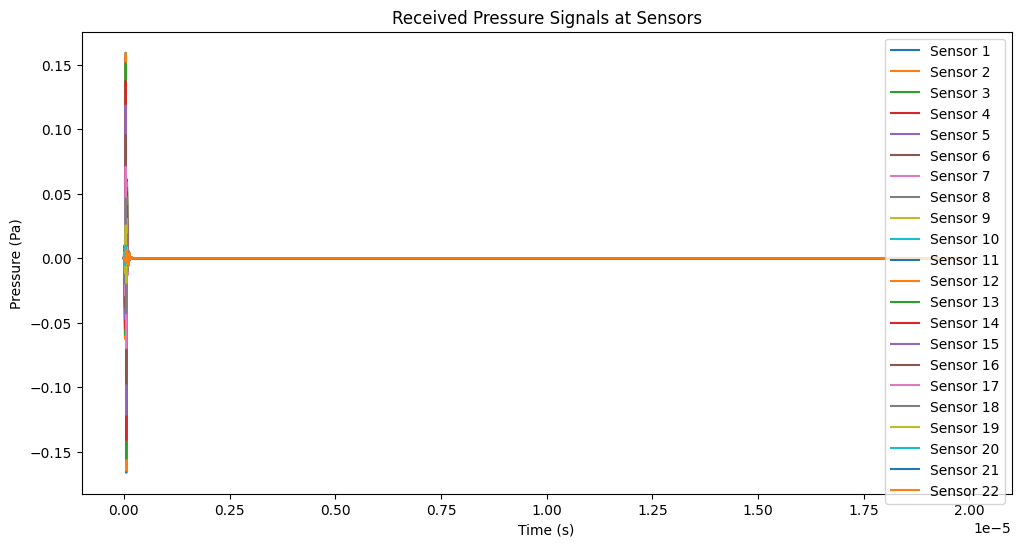

In [153]:
plt.figure(figsize=(12, 6))
for i in range(sensor_data['p'].shape[1]):
    # Use .flatten() to convert (1, Nt) to (Nt,)
    plt.plot(grid.t_array.flatten(), sensor_data['p'][:, i], label=f'Sensor {i+1}')
plt.title('Received Pressure Signals at Sensors')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (Pa)')
plt.legend()
plt.show()

In [26]:
128/4

32.0